# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Emire Kita
- **Email:** 1152700031
- **ID Dicoding:** emire_kita

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren jumlah penyewaan sepeda harian selama periode 2011–2012, serta pada periode (bulan atau musim) apa terjadi rata-rata penyewaan tertinggi dan terendah?
- **Pertanyaan 2:** Bagaimana pengaruh kondisi cuaca (suhu, kelembaban, kecepatan angin, dan kondisi cuaca) terhadap jumlah penyewaan sepeda harian, serta faktor cuaca mana yang paling berkontribusi terhadap peningkatan penyewaan selama periode 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df day.csv



In [2]:
day_df = pd.read_csv("Data/day.csv")

In [3]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- xxx
- xxx

### Assessing Data

#### Identifying Data day.csv problem

Menampilkan Statistik dari day.csv pada kolom numerik

In [4]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Menampilkan Boxplot untuk kolom "hum"

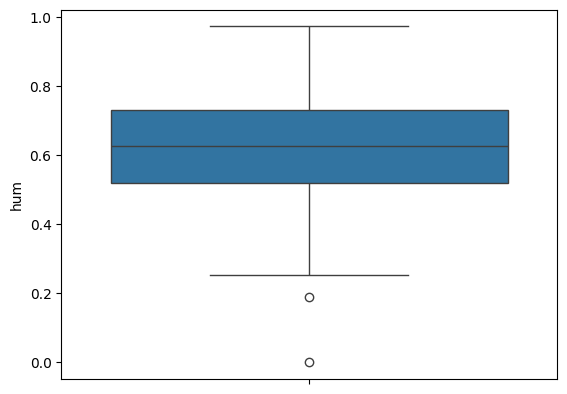

In [5]:
sns.boxplot(data=day_df['hum'])
plt.show()

In [6]:
day_df[day_df['hum'] <= 0.25]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
49,50,2011-02-19,1,0,2,0,6,0,1,0.399167,0.391404,0.187917,0.507463,532,1103,1635
68,69,2011-03-10,1,0,3,0,4,1,3,0.389091,0.385668,0.000000,0.261877,46,577,623


Menampilkan Boxplot untuk kolom "windspeed"

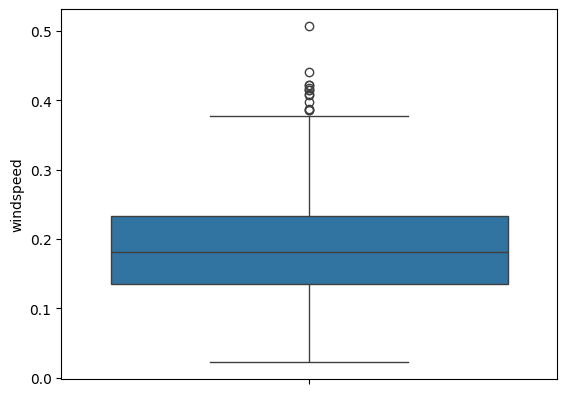

In [7]:
sns.boxplot(data=day_df['windspeed'])
plt.show()

In [8]:
day_df[day_df['windspeed'] >= 0.5]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
49,50,2011-02-19,1,0,2,0,6,0,1,0.399167,0.391404,0.187917,0.507463,532,1103,1635


In [9]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [10]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [11]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


**Steps to Take:**
- Mengganti nilai pada data yang memiliki kolom "hum" <= 0.25
- Mengganti nilai pada data yang memiliki kolom "windspeed" <= 0.5
- Mengganti Type pada kolom dteday dari object menjadi datetime


**Insight:** (Opsional)
- Terdapat Outlier pada kolom "hum" di mana nilai itu <= 0.25
- Terdapat Outlier yang terlalu jauh pada kolom "windspeed" di mana nilai itu >= 0.5
- Kolom dteday menggunakan nilai object, yang mana seharusnya itu menggunakan nilai datetime
- Tidak terdapat nilai kosong maupun data yang duplikat

### Cleaning Data

#### Fixing day.csv problem

Mengganti nilai pada data yang memiliki kolom "hum" <= 0.25

In [12]:
day_df.loc[day_df['hum'] <= 0.25, 'hum'] = day_df['hum'].median()

Memastikan apakah data sudah terganti dengan median

In [13]:
day_df[day_df['hum'] <= 0.25]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


Mengganti nilai pada data yang memiliki kolom "windspeed" >= 0.5

In [14]:
day_df.loc[day_df['windspeed'] >= 0.5, 'windspeed'] = day_df['windspeed'].median()

Memastikan apakah data sudah terganti dengan median

In [15]:
day_df[day_df['windspeed'] >= 0.5]

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt


Mengganti tipe data pada kolom dteday

In [16]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

Memastikan tipe data sudah terganti dari object menjadi datetime

In [17]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:** (Opsional)
- Berhasil mengganti data yang terdapat nilai 0 pada kolom "hum"
- Berhasil mengganti tipe data dari object menjadi datetime pada kolom "dteday"

## Exploratory Data Analysis (EDA)

### Explore day.csv

Menampilkan rangkuman parameter statistik data day.csv

In [18]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.629352,0.190040,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.254167,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.522291,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233206,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.441563,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.139566,0.076604,686.622488,1560.256377,1937.211452


Rata-rata penyewaan per Tahun

In [19]:
day_df.groupby('yr')['cnt'].mean()

yr
0    3405.761644
1    5599.934426
Name: cnt, dtype: float64

Insight:
- Penyewaan pada Tahun 1 (2012) lebih tinggi dibanding dengan Tahun 0 (2011)

Rata-rata penyewaan per Bulan

In [20]:
day_df.groupby('mnth')['cnt'].mean().sort_values(ascending=False)

mnth
6     5772.366667
9     5766.516667
8     5664.419355
7     5563.677419
5     5349.774194
10    5199.225806
4     4484.900000
11    4247.183333
3     3692.258065
12    3403.806452
2     2655.298246
1     2176.338710
Name: cnt, dtype: float64

Insight:
- Penyewaan tertinggi: Bulan 6(Juni)
- Penyewaan terendah: Bulan 1(Januari)

Rata-rata penyewaan per Musim

In [21]:
day_df.groupby('season')['cnt'].mean().sort_values(ascending=False)

season
3    5644.303191
2    4992.331522
4    4728.162921
1    2604.132597
Name: cnt, dtype: float64

Insight:
- Musim Paling ramai: 3 (Fall)
- Musim paling sepi: 1 (Springer)

Korelasi

In [22]:
day_df[['cnt','temp','atemp','hum','windspeed']].corr()

,cnt,temp,atemp,hum,windspeed
cnt,1.000000,0.627494,0.631066,-0.121426,-0.228633
temp,0.627494,1.000000,0.991702,0.123732,-0.156718
atemp,0.631066,0.991702,1.000000,0.137320,-0.182813
hum,-0.121426,0.123732,0.137320,1.000000,-0.232881
windspeed,-0.228633,-0.156718,-0.182813,-0.232881,1.000000


Insight:
- "temp" dan "atemp" adalah yang paling berpengaruh terhadap "cnt"

Rata-rata penyewaan berdasarkan kondisi cuaca

In [23]:
day_df.groupby('weathersit')['cnt'].mean()

weathersit
1    4876.786177
2    4035.862348
3    1803.285714
Name: cnt, dtype: float64

Insight:
- Cuaca dengan penyewaan tertinggi: Ketgori 1
- Cuaca dengan penyewaan terendah: Kategori 3

Analisis per variabel kondisi (temp, hum, windspeed)

In [24]:
day_df['temp_category'] = pd.cut(day_df['temp'], bins=3, labels=['Low','Medium','High'])
day_df.groupby('temp_category')['cnt'].mean()

C:\Users\Emire Kita\AppData\Local\Temp\ipykernel_23608\2318150117.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby('temp_category')['cnt'].mean()


temp_category
Low       2569.005882
Medium    4599.000000
High      5644.109848
Name: cnt, dtype: float64

In [25]:
day_df['hum_category'] = pd.cut(day_df['hum'], bins=3, labels=['Low','Medium','High'])
day_df.groupby('hum_category')['cnt'].mean()

C:\Users\Emire Kita\AppData\Local\Temp\ipykernel_23608\325691294.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby('hum_category')['cnt'].mean()


hum_category
Low       4390.030303
Medium    4821.985714
High      3843.357542
Name: cnt, dtype: float64

In [26]:
day_df['wind_category'] = pd.cut(day_df['windspeed'], bins=3, labels=['Low','Medium','High'])
day_df.groupby('wind_category')['cnt'].mean()

C:\Users\Emire Kita\AppData\Local\Temp\ipykernel_23608\4130583137.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby('wind_category')['cnt'].mean()


wind_category
Low       4893.784722
Medium    4421.707447
High      3294.134328
Name: cnt, dtype: float64

**Insight:**
- Kategori temp dengan penyewaan tertinggi: Medium(Menengah)
- Kategori hum dengan penyewaan tertinggi: Medium(Menengah)
- Kategori windspeed dengan penyewaan tertinggi: Low(Rendah)

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren jumlah penyewaan sepeda harian selama periode 2011–2012, serta pada periode (bulan atau musim) apa terjadi rata-rata penyewaan tertinggi dan terendah?

Menampilkan Grafik Tren Penyewaan(cnt) setiap harinya

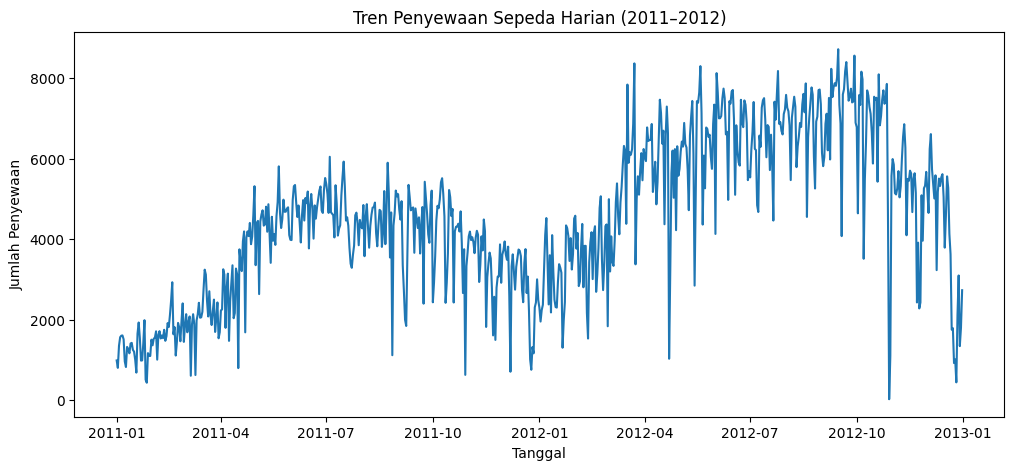

In [27]:
plt.figure(figsize=(12,5))
plt.plot(day_df['dteday'], day_df['cnt'])
plt.title('Tren Penyewaan Sepeda Harian (2011–2012)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penyewaan')
plt.show()

Explanatory: Tren Penyewaan menunjukkan pola meningkat di Tahun 20212 dibandingkan Tahun 2011. Hal ini menandakan bahwa adanya pertumbuhan penggunaan bike sharing.

Menampilkan grafik rata-rata Penyewaan(cnt) per Bulan

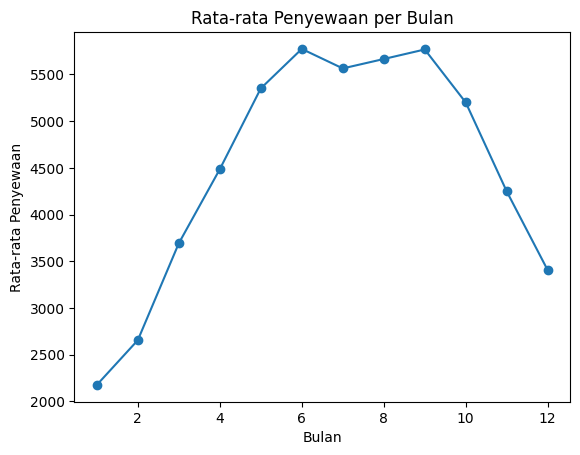

In [28]:
monthly_avg = day_df.groupby('mnth')['cnt'].mean()

monthly_avg.plot(marker='o')
plt.title('Rata-rata Penyewaan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Penyewaan')
plt.show()

Explanatory: Penyewaan tertinggi ada pada bulan-bulan pertengahan tahun, sedangkan penyewaan terendah ada pada awal dan akhir tahun. Hal ini menandakan adanya pola bulanan dalam penggunaan bike sharing.

Menampilkan Distribusi Penyewaan(cnt) berdasarkan Musim(season)

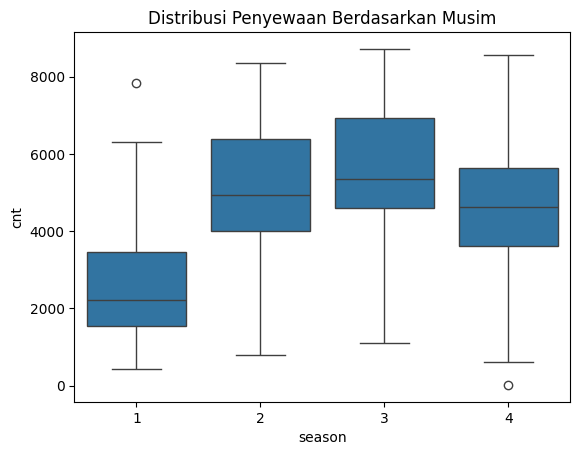

In [29]:
sns.boxplot(x='season', y='cnt', data=day_df)
plt.title('Distribusi Penyewaan Berdasarkan Musim')
plt.show()

Explanatory: Musim 2(summer) dan 3(fall)  menjadi musim dengan penyewaan tertinggi, sedangkan musim 1(winter) menjadi yang terendah. Hal ini menunjukkan musim berpengaruh pada minat penyewaan sepeda.

Menampilkan perbandingan penyewaan pada Tahun 2011 dengan Tahun 2012

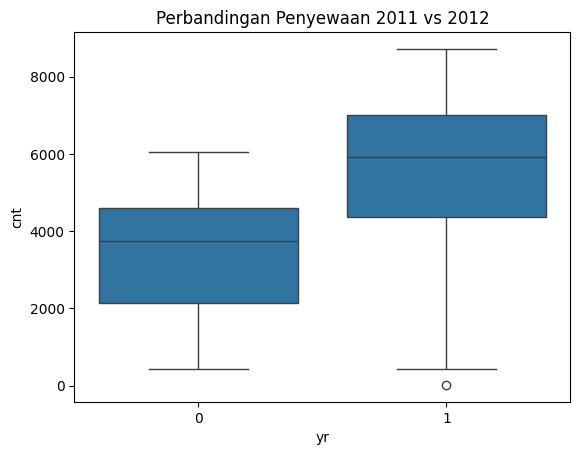

In [30]:
sns.boxplot(x='yr', y='cnt', data=day_df)
plt.title('Perbandingan Penyewaan 2011 vs 2012')
plt.show()

Explanatory: Tahun 2012 memiliki distribusi penyewaan yang lebih tinggi dibandingkan 2011, menunjukkan adanya peningkatan adopsi layanan di Tahun 2012.

### Pertanyaan 2: Bagaimana pengaruh kondisi cuaca (suhu, kelembaban, kecepatan angin, dan kondisi cuaca) terhadap jumlah penyewaan sepeda harian, serta faktor cuaca mana yang paling berkontribusi terhadap peningkatan penyewaan selama periode 2011–2012?

Menampilkan Korelasi antara kondisi cuaca (temp, atemp, hum, windspeed) dengan cnt

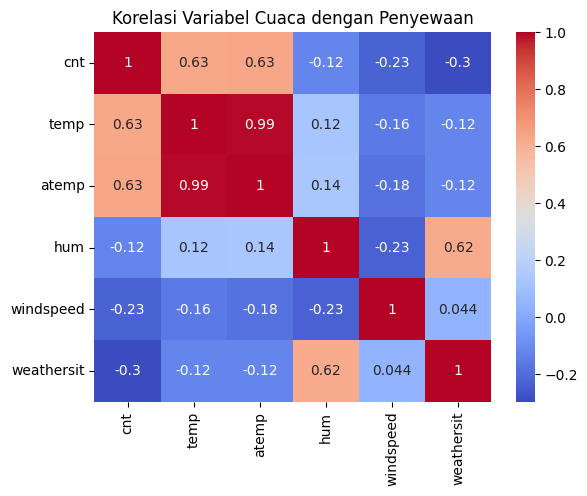

In [31]:
corr = day_df[['cnt','temp','atemp','hum','windspeed','weathersit']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Korelasi Variabel Cuaca dengan Penyewaan')
plt.show()

Explanatory: suhu(temp) memiliki korelasi positif paling kuat terhadap jumlah penyewaan.

Menampilkan pengaruh suhu(temp) terhadap Penyewaan(cnt)

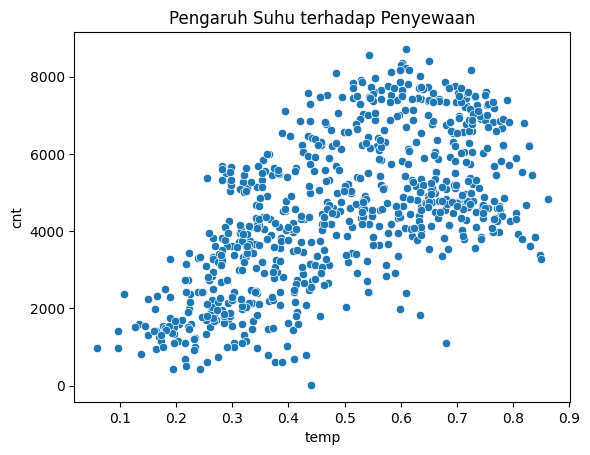

In [32]:
sns.scatterplot(x='temp', y='cnt', data=day_df)
plt.title('Pengaruh Suhu terhadap Penyewaan')
plt.show()

Explanatory: Terlihat bahwa peningkatan suhu cenderung diikuti oleh peningkatan jumlah penyewaan, menunjukkan bahwa kondisi hangat mendorong aktivitas bersepeda.

Menampilkan pengaruh kelembaban(hum) terhadap penyewaan(cnt)

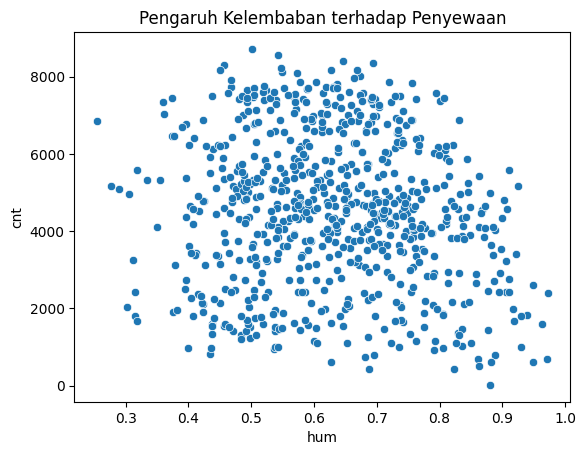

In [33]:
sns.scatterplot(x='hum', y='cnt', data=day_df)
plt.title('Pengaruh Kelembaban terhadap Penyewaan')
plt.show()

Explanatory: Kelembaban yang tinggi cenderung menurunkan jumlah penyewaan, kemungkinan karena kondisi udara yang kurang nyaman.

Menampilkan pengaruh kecepatan angin(windspeed) terhadap penyewaan(cnt)

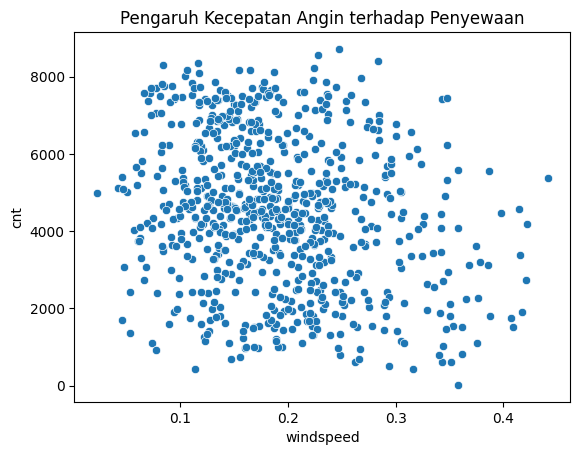

In [34]:
sns.scatterplot(x='windspeed', y='cnt', data=day_df)
plt.title('Pengaruh Kecepatan Angin terhadap Penyewaan')
plt.show()

Explanatory: Kecepatan angin yang rendah cenderung lebih tinggi jumlah penyewaannya. Menunjukkan bahwa kecepatan angin yang rendah nyaman untuk bersepeda.

Menampilkan pengaruh cuaca(weathersit) terhadap penyewaan(cnt)

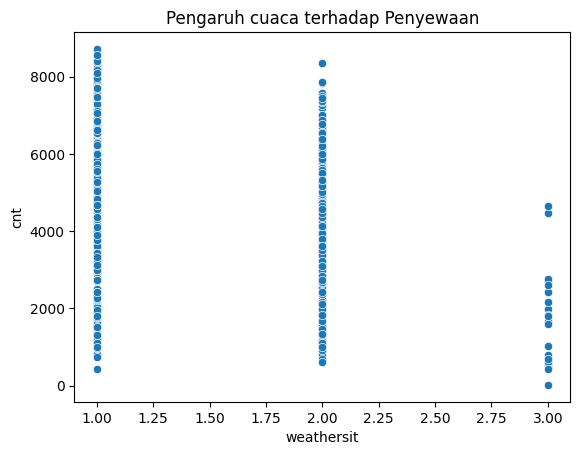

In [35]:
sns.scatterplot(x='weathersit', y='cnt', data=day_df)
plt.title('Pengaruh cuaca terhadap Penyewaan')
plt.show()

Explanatory: Kondisi cuaca pada kategori 3 lebih rendah jumlah penyewaannya dbanding kondisi 1 dan 2. Ini berarti cuaca pada kategori 3 kurang bersahabat untuk bersepeda.

**Insight:**
- Penyewaan sepeda mengalami peningkatan dari tahun 2011 ke 2012 dengan pola musiman yang jelas, di mana permintaan tertinggi terjadi pada pertengahan tahun dan terendah pada musim dingin atau awal tahun.
- Faktor cuaca memiliki pengaruh signifikan terhadap penyewaan, dengan suhu sebagai faktor paling dominan yang meningkatkan permintaan, sementara kelembaban dan kondisi cuaca buruk menurunkan jumlah penyewaan.

## Analisis Lanjutan (Opsional)

In [36]:
day_df['demand_cluster'] = pd.qcut(day_df['cnt'], q=3, labels=['Low', 'Medium', 'High'])

In [37]:
day_df['demand_cluster'].value_counts()

demand_cluster
Low       244
Medium    244
High      243
Name: count, dtype: int64

In [38]:
day_df.groupby('demand_cluster')[['cnt','temp','hum','windspeed']].mean()

C:\Users\Emire Kita\AppData\Local\Temp\ipykernel_23608\1307804944.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby('demand_cluster')[['cnt','temp','hum','windspeed']].mean()


,cnt,temp,hum,windspeed
demand_cluster,,,,
Low,2312.065574,0.333430,0.636429,0.212641
Medium,4522.225410,0.558381,0.646090,0.182005
High,6687.703704,0.594751,0.605438,0.175413


In [39]:
day_df.groupby(['demand_cluster','weathersit']).size()

C:\Users\Emire Kita\AppData\Local\Temp\ipykernel_23608\1883841905.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(['demand_cluster','weathersit']).size()


demand_cluster  weathersit
Low             1             121
                2             104
                3              19
Medium          1             160
                2              82
                3               2
High            1             182
                2              61
                3               0
dtype: int64

In [40]:
day_df.groupby(['demand_cluster','season']).size()

C:\Users\Emire Kita\AppData\Local\Temp\ipykernel_23608\474539619.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(['demand_cluster','season']).size()


demand_cluster  season
Low             1         140
                2          37
                3          13
                4          54
Medium          1          33
                2          71
                3          79
                4          61
High            1           8
                2          76
                3          96
                4          63
dtype: int64

Interpretasi:
- Low Demand: penyewaan(cnt) rendah, suhu rendah, kelembaban sedang, kebanyakan pada saat musim 1(winter).
- Medium Demand: Kondisi normal, transisi musim.
- High Demand: penyewaan(cnt) tinggi, suhu normal, cuaca cerah dan mendukung.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan analisis data tahun 2011–2012, jumlah penyewaan sepeda menunjukkan tren peningkatan dari waktu ke waktu, terutama pada tahun 2012 yang memiliki rata-rata penyewaan lebih tinggi dibandingkan 2011.
Selain itu, adanya pola musiman yang jelas, di mana: Penyewaan tertinggi terjadi pada pertengahan Tahun(Musim 2(summer) dan 3(fall)). Sedangkan penyewaan terendah ada pada awal Tahun(Musim 1(winter))
- **Conclusion pertanyaan 2:** Berdasarkan analisis data, faktor suhu(temp) menjadi pengaruh paling tinggi terhadap penyewaan sepeda, sementara faktor lainnya cenderung merata.
- ...

**Rekomendasi Action Item:**
- Fokuskan operasional pada periode dengan permintaan tinggi (musim panas/gugur). Seperti penambahan jumlah sepeda dan pengoptimalan distribusi sepeda.
- Strategi saat musim yang sepi: Promo/diskon khusus atau paket langganan murah.

Menyimpan data yang sudah dimodifikasi

In [41]:
day_df.to_csv("main_data.csv", index=False)